<a href="https://colab.research.google.com/github/oj-o/T-A/blob/main/2_MMDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# 현재 시스템의 GPU 상태 확인(모델, 메모리 사용량 등)
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


#0. MMDetection github
**google mmdetection 검색**
- https://github.com/open-mmlab/mmdetection


# 1. Installation
**installation 링크**
- https://mmdetection.readthedocs.io/en/latest/get_started.html

## Install on Google Colab

### Step 0. Configuring the Colab runtime

- PyTorch/CUDA version on Google Colab

In [7]:
import torch
print(torch.__version__);print(torch.version.cuda)

2.6.0+cu124
12.4


In [8]:
# 현재 prebuilt 된 mmcv 2.1.0을 사용하기 위해서는 Pytorch 2.1이 필요 (아래 문서 참조)
# https://mmcv.readthedocs.io/en/latest/get_started/installation.html
# pip install mmcv==2.1.0 -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.1/index.html

- Numpy Downgrade

In [9]:
# 현재 Google Colab에는 numpy 2.x 설치로 pytroch 2.1과 호환되지 않아서 downgrade
import numpy as np
print(np.__version__)

!pip install 'numpy<2'

2.0.2


- Pytorch Uninstall & Install 2.1

In [10]:
!pip uninstall torch -y
# https://pytorch.org/get-started/previous-versions/
!pip install torch==2.1 torchvision==0.16.0

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.2/670.2 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.0 MB/s eta 0:00:00
 

In [1]:
import torch, torchvision
print("torch version:",torch.__version__, "torchvision version:", torchvision.__version__)

torch version: 2.1.0+cu121 torchvision version: 0.16.0+cu121


### Step 1. Install MMEngine and MMCV using MIM.

In [2]:
# Step 1. Install MMEngine and MMCV using MIM.
# !pip3 install openmim
# !mim install mmengine
# !mim install "mmcv>=2.0.0,<2.1.0"

In [3]:
!pip3 install openmim

In [4]:
!mim install mmengine

Looking in links: https://download.openmmlab.com/mmcv/dist/cu121/torch2.1.0/index.html


In [8]:
!pip install mmcv==2.1.0 -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.1/index.html

Looking in links: https://download.openmmlab.com/mmcv/dist/cu121/torch2.1/index.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.1/94.1 MB 8.9 MB/s eta 0:00:00


### Step 2. Install MMDetection from the source.

In [7]:
!git clone https://github.com/open-mmlab/mmdetection.git
%cd mmdetection
!pip install -e .

Cloning into 'mmdetection'...
remote: Enumerating objects: 38023, done.
remote: Total 38023 (delta 0), reused 0 (delta 0), pack-reused 38023 (from 1)
Receiving objects: 100% (38023/38023), 63.25 MiB | 23.04 MiB/s, done.
Resolving deltas: 100% (26223/26223), done.
/content/mmdetection/mmdetection
Obtaining file:///content/mmdetection/mmdetection
  Preparing metadata (setup.py) ... done
  Attempting uninstall: mmdet
    Found existing installation: mmdet 3.3.0
    Uninstalling mmdet-3.3.0:
      Successfully uninstalled mmdet-3.3.0
  Running setup.py develop for mmdet


### Step 3. Verification

In [9]:
import mmdet
print(mmdet.__version__)

3.3.0


### Step 4. Verify the installation

- github의 demo 디렉토리 아래 [MMDet_InstanceSeg_Tutorial.ipynb](https://github.com/open-mmlab/mmdetection/blob/main/demo/MMDet_InstanceSeg_Tutorial.ipynb) 파일 참조

In [10]:
# Check Pytorch installation
import torch #, torchvision
print("torch version:",torch.__version__, "cuda:",torch.cuda.is_available())

# Check MMDetection installation
import mmdet
print("mmdetection:",mmdet.__version__)

# Check mmcv installation
import mmcv
print("mmcv:",mmcv.__version__)

# Check mmengine installation
import mmengine
print("mmengine:",mmengine.__version__)

torch version: 2.1.0+cu121 cuda: False
mmdetection: 3.3.0
mmcv: 2.1.0
mmengine: 0.10.7


In [11]:
!mim download mmdet --config faster-rcnn_r50_fpn_2x_coco --dest ./checkpoints

processing faster-rcnn_r50_fpn_2x_coco...
downloading ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 MiB 41.9 MB/s eta 0:00:00
Successfully downloaded faster_rcnn_r50_fpn_2x_coco_bbox_mAP-0.384_20200504_210434-a5d8aa15.pth to /content/mmdetection/mmdetection/checkpoints
Successfully dumped faster-rcnn_r50_fpn_2x_coco.py to /content/mmdetection/mmdetection/checkpoints


In [12]:
import mmcv
import mmengine
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
# Choose to use a config and initialize the detector
config_file = 'configs/faster_rcnn/faster-rcnn_r50_fpn_2x_coco.py'
# Setup a checkpoint file to load
checkpoint_file = 'checkpoints/faster_rcnn_r50_fpn_2x_coco_bbox_mAP-0.384_20200504_210434-a5d8aa15.pth'

# register all modules in mmdet into the registries
register_all_modules()

# build the model from a config file and a checkpoint file
model = init_detector(config_file, checkpoint_file, device='cpu')  # or device='cuda:0'

Loads checkpoint by local backend from path: checkpoints/faster_rcnn_r50_fpn_2x_coco_bbox_mAP-0.384_20200504_210434-a5d8aa15.pth


In [13]:
# Use the detector to do inference
image = mmcv.imread('demo/demo.jpg',channel_order='rgb')
result = inference_detector(model, image)
print(result)

<DetDataSample(

    META INFORMATION
    ori_shape: (427, 640)
    img_id: 0
    scale_factor: (1.8734375, 1.873536299765808)
    pad_shape: (800, 1216)
    img_path: None
    batch_input_shape: (800, 1216)
    img_shape: (800, 1199)

    DATA FIELDS
    pred_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            bboxes: tensor([[4.8070e+02, 1.1011e+02, 5.2302e+02, 1.3019e+02],
                        [4.3118e+02, 1.0519e+02, 4.8334e+02, 1.3251e+02],
                        [2.9399e+02, 1.1678e+02, 3.8011e+02, 1.4986e+02],
                        [3.9579e+02, 1.1070e+02, 4.3465e+02, 1.3336e+02],
                        [2.2602e+02, 1.7805e+02, 4.5482e+02, 3.8014e+02],
                        [5.0208e-01, 1.1110e+02, 6.3248e+01, 1.4431e+02],
                        [1.6715e+02, 1.0923e+02, 2.1675e+02, 1.3919e+02],
                        [5.9138e+02, 1.1034e+02, 6.1360e+02, 1.2605e+02],
                        [6.0909e+02, 1.1081e+0

In [14]:
from mmdet.registry import VISUALIZERS
# init visualizer(run the block only once in jupyter notebook)
visualizer = VISUALIZERS.build(model.cfg.visualizer)
# the dataset_meta is loaded from the checkpoint and
# then pass to the model in init_detector
visualizer.dataset_meta = model.dataset_meta

/usr/local/lib/python3.11/dist-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


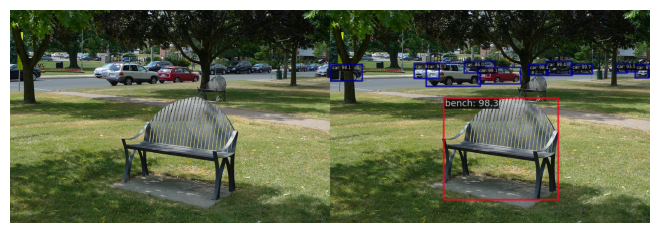

In [15]:
# show the results
visualizer.add_datasample(
    'result',
    image,
    data_sample=result,
    draw_gt = True,
    wait_time=0,
    pred_score_thr = 0.6
)
visualizer.show()

# 새 섹션